In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/RUL_FD002.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/test_FD003.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/Damage Propagation Modeling.pdf
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/readme.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD003.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/test_FD004.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD004.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/test_FD002.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD001.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD002.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/RUL_FD001.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/RUL_FD004.txt
/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/RUL_FD003.txt

## Análise Exploratória (EDA)

Carregando o arquivo em: /kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD001.txt
Dados carregados com sucesso! Tamanho da matriz: (20631, 26)

Gerando o painel de gráficos para o Motor 1...


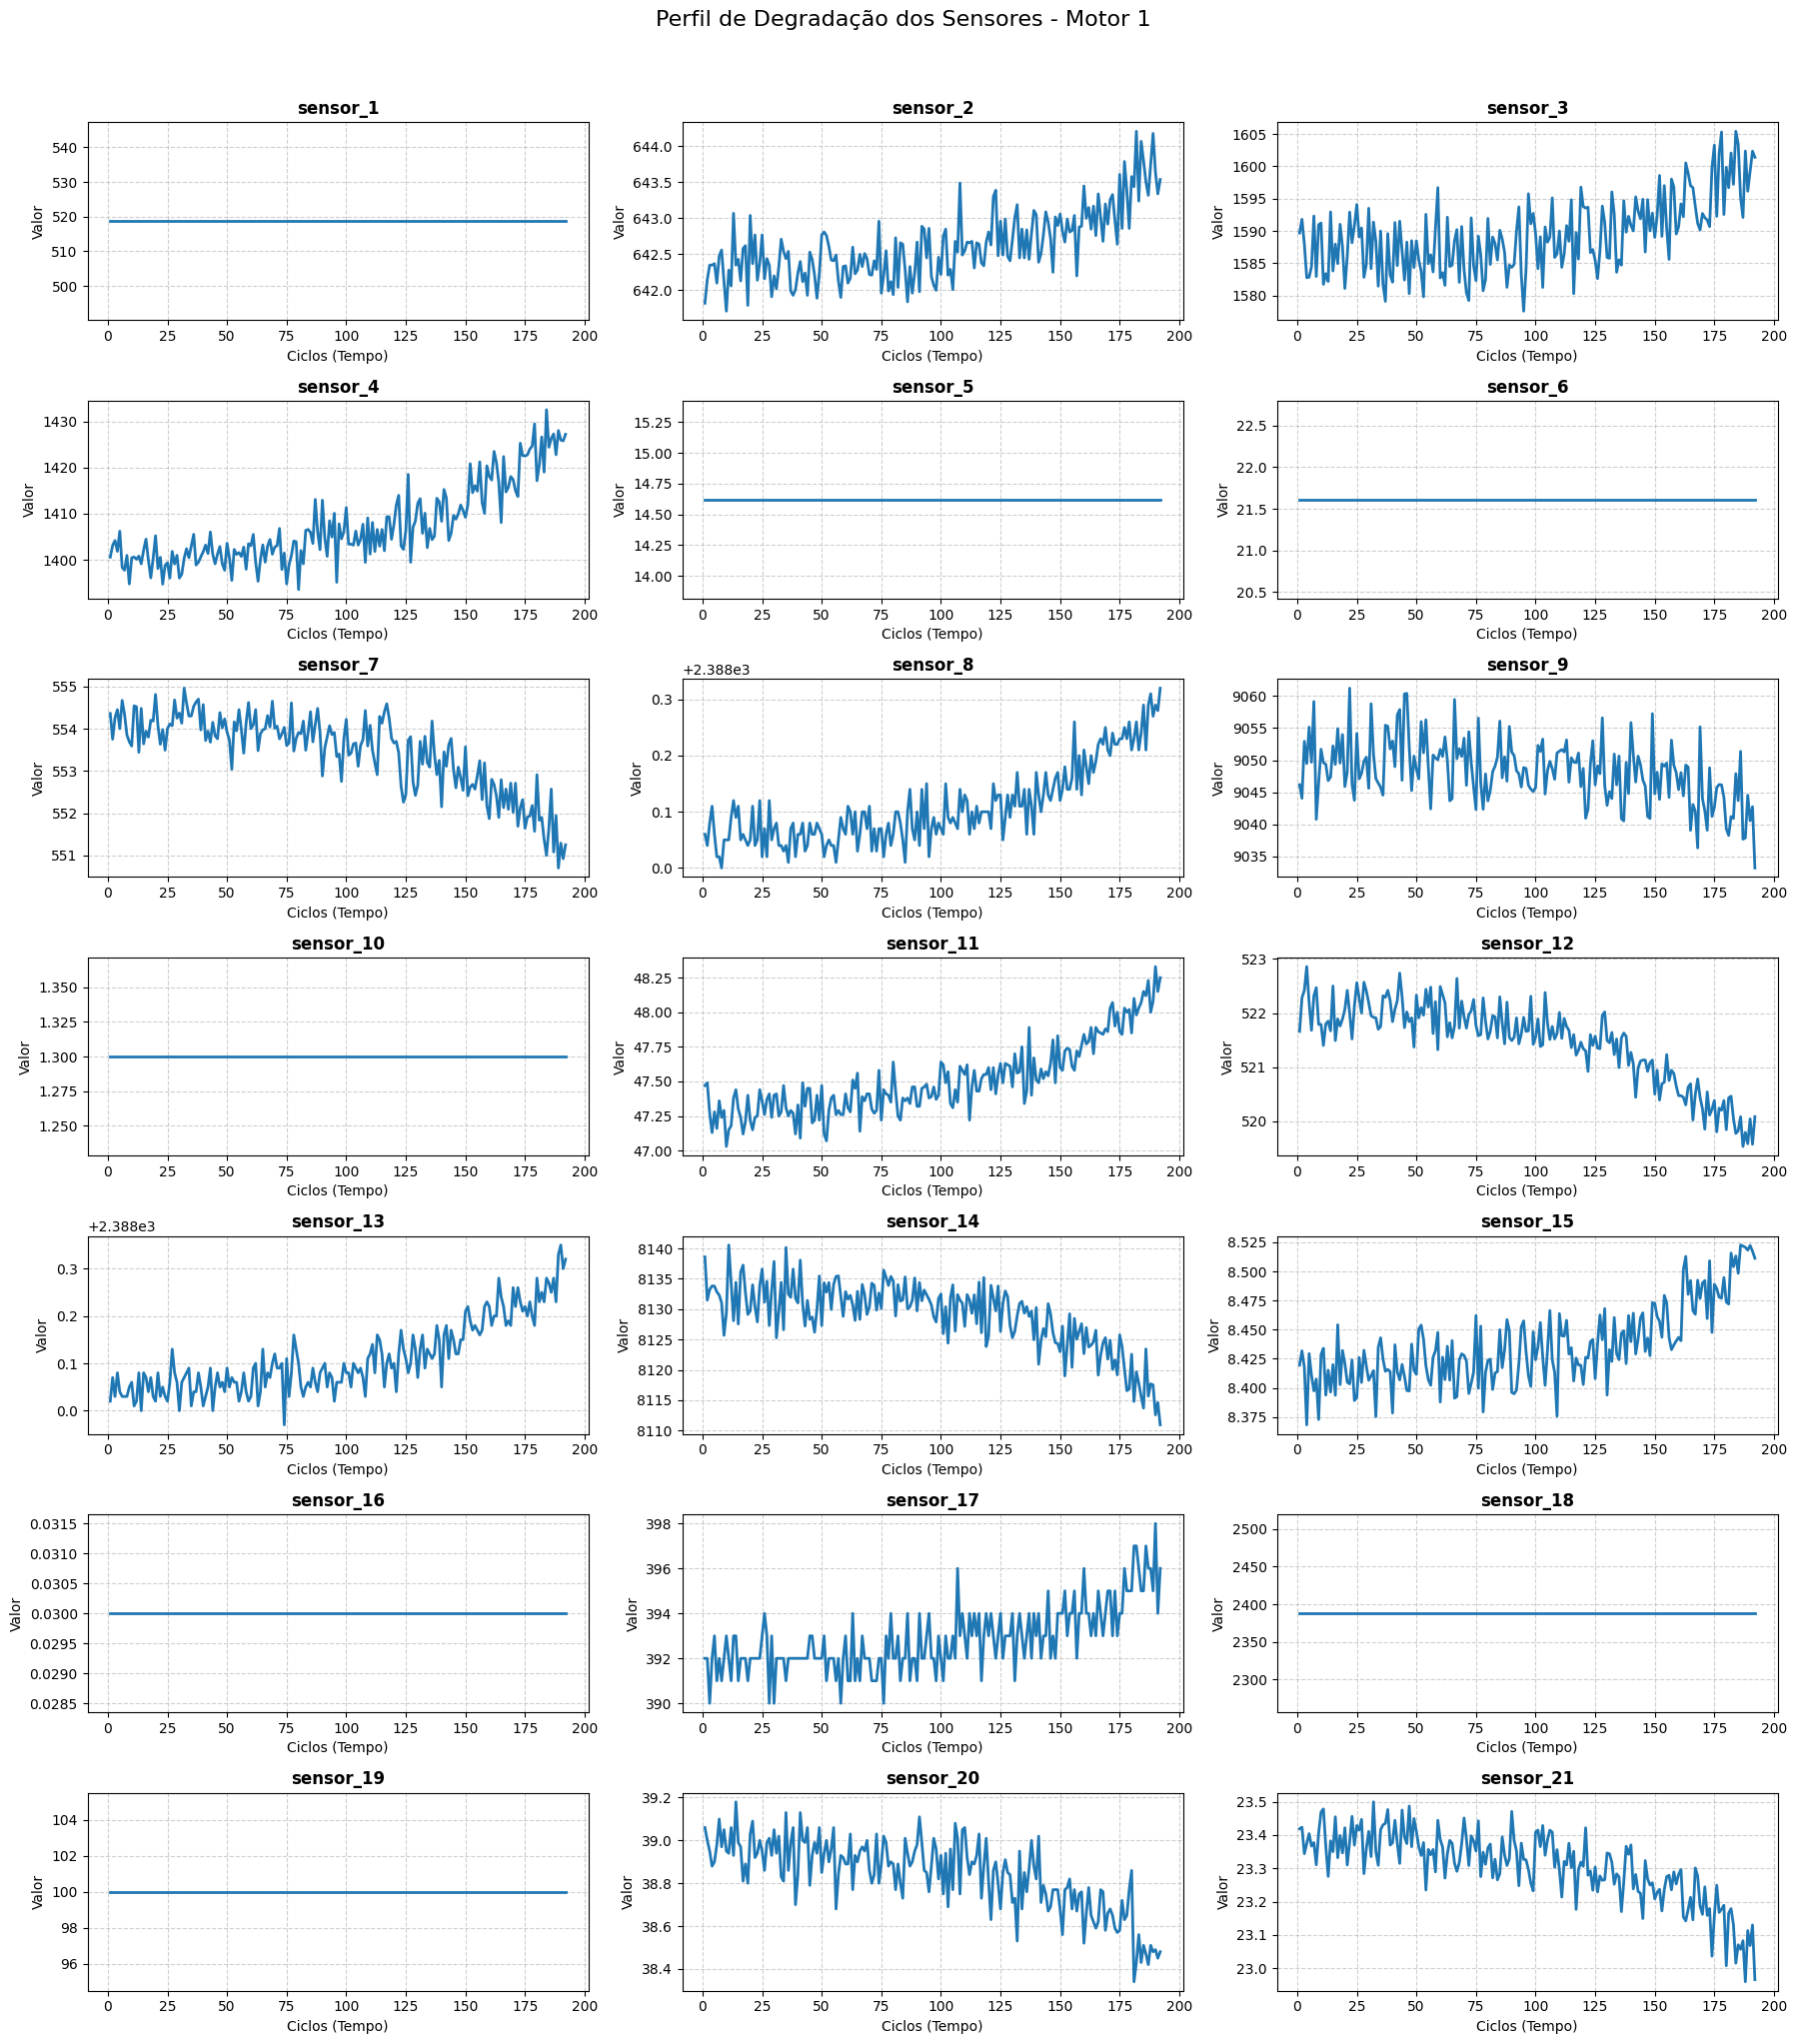

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# FASE 1: Carregar os Dados
# ==========================================
# Cole o caminho exato do seu arquivo aqui (seja no Kaggle ou no seu PC local)
caminho_arquivo = '/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/train_FD001.txt'

# Nomes das colunas conforme a documentação oficial da NASA
colunas = ['motor_id', 'ciclo', 'config_op_1', 'config_op_2', 'config_op_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

print(f"Carregando o arquivo em: {caminho_arquivo}")

# Carregar o arquivo TXT para um DataFrame do Pandas
df_treino = pd.read_csv(caminho_arquivo, sep=r'\s+', header=None, names=colunas)
print(f"Dados carregados com sucesso! Tamanho da matriz: {df_treino.shape}\n")


# ==========================================
# FASE 2: Análise Exploratória (EDA)
# ==========================================
def plotar_degradacao_motor(df, id_do_motor):
    """Gera um painel com gráficos de linha para todos os 21 sensores."""
    # Filtrar apenas o motor escolhido
    dados_motor = df[df['motor_id'] == id_do_motor]
    sensores = [f'sensor_{i}' for i in range(1, 22)]
    
    # Configurar a grade de imagens (7 linhas x 3 colunas)
    plt.figure(figsize=(18, 20))
    plt.suptitle(f'Perfil de Degradação dos Sensores - Motor {id_do_motor}', fontsize=16, y=1.02)
    
    for i, sensor in enumerate(sensores, start=1):
        plt.subplot(7, 3, i)
        plt.plot(dados_motor['ciclo'], dados_motor[sensor], color='#1f77b4', linewidth=2)
        plt.title(sensor, fontsize=12, fontweight='bold')
        plt.xlabel('Ciclos (Tempo)', fontsize=10)
        plt.ylabel('Valor', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.savefig("meu_grafico_degradacao.png", dpi=300, bbox_inches='tight')
    plt.show()

# Executar a visualização para o Motor 1
print("Gerando o painel de gráficos para o Motor 1...")
plotar_degradacao_motor(df_treino, id_do_motor=1)

## Pré-processamento do Dataset

In [3]:
from sklearn.preprocessing import MinMaxScaler

print("Iniciando o pré-processamento...")

# ==========================================
# 1. Calcular o RUL (A Contagem Regressiva)
# ==========================================
# Pegamos o ciclo máximo que cada motor atingiu antes de falhar
vida_maxima = df_treino.groupby('motor_id')['ciclo'].max()
df_treino = df_treino.merge(vida_maxima.to_frame(name='vida_maxima'), left_on='motor_id', right_index=True)

# O RUL é a vida máxima do motor menos o ciclo atual
df_treino['RUL'] = df_treino['vida_maxima'] - df_treino['ciclo']
df_treino.drop('vida_maxima', axis=1, inplace=True)

# ==========================================
# 2. Cortar o Peso Morto (Feature Selection)
# ==========================================
# Removendo configurações fixas e sensores que não variam (linhas retas)
colunas_inuteis = [
    'config_op_1', 'config_op_2', 'config_op_3', 
    'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'
]
df_treino.drop(colunas_inuteis, axis=1, inplace=True)

# ==========================================
# 3. Nivelar o Terreno (Normalização)
# ==========================================
# Descobrimos quais colunas de sensores sobraram
sensores_restantes = [col for col in df_treino.columns if 'sensor' in col]

# Aplicamos o "rolo compressor" para deixar tudo entre 0 e 1
scaler = MinMaxScaler()
df_treino[sensores_restantes] = scaler.fit_transform(df_treino[sensores_restantes])

print(f"Pré-processamento concluído! O dataset emagreceu e agora tem o tamanho: {df_treino.shape}")
print("\nVisualizando as primeiras linhas prontas (repare na nova coluna RUL no final):")
display(df_treino.head())

Iniciando o pré-processamento...
Pré-processamento concluído! O dataset emagreceu e agora tem o tamanho: (20631, 18)

Visualizando as primeiras linhas prontas (repare na nova coluna RUL no final):


,motor_id,ciclo,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


### 1. PREPARAÇÃO DOS DADOS (JANELAMENTO TEMPORAL E RUL CLIPPING)

In [5]:
# O modelo precisa receber os dados em blocos 3D: (Amostras, Tempo, Sensores)
SEQUENCE_LENGTH = 30 # Tamanho da janela de tempo (30 ciclos)

def processar_dados_temporais(df, sequence_length, colunas_sensores):
    df_proc = df.copy()
    if 'RUL' in df_proc.columns:
        df_proc['RUL'] = df_proc['RUL'].clip(upper=130) # Clipping para focar na degradação final
    
    seq_gen, label_gen = [], []
    
    # [CORREÇÃO AQUI]: Trocamos 'unit_nr' por 'motor_id' para bater com o seu dataframe!
    for engine_id in df_proc['motor_id'].unique():
        engine_data = df_proc[df_proc['motor_id'] == engine_id]
        sensor_data = engine_data[colunas_sensores].values
        rul_data = engine_data['RUL'].values if 'RUL' in engine_data.columns else None
        
        for i in range(len(engine_data) - sequence_length + 1):
            seq_gen.append(sensor_data[i:i + sequence_length])
            if rul_data is not None:
                label_gen.append(rul_data[i + sequence_length - 1])
                
    return np.array(seq_gen), np.array(label_gen)

### 2. INOVAÇÕES ARQUITETURAIS E MATEMÁTICAS

In [6]:
# INOVAÇÃO 1: Atenção Focada nos Sensores (Dynamic Sensor Weighting)
class DynamicSensorWeights(layers.Layer):
    """
    Aprende a dar pesos diferentes para cada sensor dependendo da fase de vida do motor.
    """
    def __init__(self, num_sensors, **kwargs):
        super(DynamicSensorWeights, self).__init__(**kwargs)
        self.num_sensors = num_sensors
        self.dense1 = layers.Dense(32, activation='relu')
        self.dense2 = layers.Dense(num_sensors, activation='sigmoid')

    def call(self, inputs):
        # inputs shape: (batch, time_steps, num_sensors)
        # Extrai o contexto global da janela de 30 ciclos
        global_context = tf.reduce_mean(inputs, axis=1)
        # Gera os pesos (de 0 a 1) para os sensores
        sensor_weights = self.dense2(self.dense1(global_context))
        # Expande para multiplicar ao longo do tempo
        sensor_weights = tf.expand_dims(sensor_weights, axis=1)
        # Aplica a máscara de pesos nos dados originais
        return inputs * sensor_weights

# INOVAÇÃO 3: Função de Perda Assimétrica (Orientada ao Risco)
def asymmetric_loss(y_true, y_pred):
    """
    Penaliza severamente o modelo se ele prever que o motor vai durar mais do que a realidade (y_pred > y_true).
    Baseado na Score Function oficial da NASA para o CMAPSS.
    """
    d = y_pred - y_true
    # Se d > 0 (Superestimou): Custo exponencial severo (fator 13)
    # Se d < 0 (Subestimou): Custo exponencial suave (fator 10)
    loss = tf.where(d > 0, 
                    K.exp(d / 13.0) - 1.0, 
                    K.exp(-d / 10.0) - 1.0)
    return K.mean(loss)

### 3. CONSTRUÇÃO DA REDE (ROTAS PARALELAS)

In [7]:
def build_asff_net(seq_length, num_features):
    # Entrada
    inputs = layers.Input(shape=(seq_length, num_features), name='sensor_inputs')
    
    # [1] Aplica os pesos dinâmicos aos sensores
    weighted_input = DynamicSensorWeights(num_features)(inputs)
    
    # [2] ROTAS PARALELAS DE EXTRAÇÃO
    # Rota A: LSTM (Foco na tendência longa de degradação)
    x_lstm = layers.LSTM(64, return_sequences=True)(weighted_input)
    x_lstm = layers.LSTM(32, return_sequences=False)(x_lstm)
    
    # Rota B: CNN 1D (Foco em picos, anomalias e vibrações repentinas)
    x_cnn = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(weighted_input)
    x_cnn = layers.GlobalMaxPooling1D()(x_cnn) # Pega o sinal mais forte da janela
    
    # Rota C: Skip Connection (Conexão Residual com os dados brutos)
    x_skip = layers.Flatten()(weighted_input)
    x_skip = layers.Dense(32, activation='relu')(x_skip)
    
    # [3] FUSÃO (Concatenando todas as rotas)
    concat = layers.Concatenate()([x_lstm, x_cnn, x_skip])
    
    # [4] DECISÃO FINAL
    x = layers.Dropout(0.3)(concat)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear', name='rul_output')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="ASFF-Net")
    
    # Compilando com a Função de Perda Customizada e AdamW (Weight Decay)
    # Obs: Se o Keras estiver numa versão mais antiga que 2.11, troque AdamW por Adam.
    try:
        optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
    except AttributeError:
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss=asymmetric_loss, metrics=['mae'])
    
    return model

### 4. AVALIAÇÃO E MÉTRICAS (Score Oficial NASA + MAE + RMSE)

In [8]:
def calcular_score_cmapss(y_true, y_pred):
    """
    Calcula o Score oficial do CMAPSS (NASA).
    Penaliza predições tardias (superestimação) muito mais do que predições precoces.
    """
    d = y_pred.flatten() - y_true.flatten()
    score = 0.0
    for di in d:
        if di < 0:
            score += np.exp(-di / 10.0) - 1.0
        else:
            score += np.exp(di / 13.0) - 1.0
    return score

def avaliar_modelo(model, X, y, history=None, nome_conjunto="Teste"):
    
    # Agora o print é dinâmico!
    print(f"\n--- Gerando Predições no Conjunto de {nome_conjunto} ---")
    y_pred = model.predict(X)
    
    # 1. Cálculo das Métricas
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    nasa_score = calcular_score_cmapss(y, y_pred)
    
    print(f"✅ MAE (Erro Médio Absoluto): {mae:.2f} ciclos")
    print(f"✅ RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} ciclos")
    print(f"🚀 SCORE OFICIAL NASA (CMAPSS): {nasa_score:.2f}")

### 5. EXECUÇÃO (A ORDEM PARA TREINAR E AVALIAR)

In [13]:
# 1. Definir os sensores que sobreviveram à sua limpeza
colunas_sensores = sensores_restantes 

print("Preparando dados temporais (Janelas de 30 ciclos)...")
# Passamos a variável correta para a função:
X_train_full, y_train_full = processar_dados_temporais(df_treino, SEQUENCE_LENGTH, colunas_sensores)

# Separando os últimos 20% do df_treino para atuar como nosso teste de validação gráfico
split_idx = int(len(X_train_full) * 0.8)
X_train, y_train = X_train_full[:split_idx], y_train_full[:split_idx]
X_val, y_val = X_train_full[split_idx:], y_train_full[split_idx:]

print("Construindo a Arquitetura ASFF-Net...")
model = build_asff_net(SEQUENCE_LENGTH, len(colunas_sensores))
model.summary()

# 4. Treinar com Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Iniciando o treino da ASFF-Net...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Preparando dados temporais (Janelas de 30 ciclos)...
Construindo a Arquitetura ASFF-Net...


Model: "ASFF-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_inputs       │ (None, 30, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dynamic_sensor_wei… │ (None, 30, 15)    │      1,007 │ sensor_inputs[0]… │
│ (DynamicSensorWeig… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 30, 64)    │     20,480 │ dynamic_sensor_w… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 28, 32)    │      1,472 │ dynamic_sensor_w… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 450)       │          0 │ dynamic_sensor_w… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │     14,432 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      3,104 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         33 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,944 (206.81 KB)

 Trainable params: 52,944 (206.81 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando o treino da ASFF-Net...
Epoch 1/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 20813.2500 - mae: 54.3684 - val_loss: 221.5514 - val_mae: 42.3670
Epoch 2/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 250.6999 - mae: 41.3126 - val_loss: 95.9190 - val_mae: 39.2853
Epoch 3/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 148.0361 - mae: 38.7156 - val_loss: 56.4790 - val_mae: 36.0155
Epoch 4/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 92.8279 - mae: 35.7016 - val_loss: 33.5256 - val_mae: 32.3089
Epoch 5/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 59.3348 - mae: 32.7872 - val_loss: 22.8480 - val_mae: 29.4403
Epoch 6/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 43.6338 - mae: 30.2405 - val_loss: 17.1528 - val_mae: 27.2650
Epoch 7/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 38.2302 - mae: 28.7743 - val_loss: 14.3327 - val_mae: 25.4695
Epoch 8/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 30.6806 - mae: 27.3423 - val_l

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Avaliar e desenhar os gráficos usando os dados de validação que criámos!
# Passando explicitamente o argumento nome_conjunto!
avaliar_modelo(model, X_val, y_val, history, nome_conjunto="Validação (Simulado)")


--- Gerando Predições no Conjunto de Validação (Simulado) ---
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
✅ MAE (Erro Médio Absoluto): 13.45 ciclos
✅ RMSE (Raiz do Erro Quadrático Médio): 16.65 ciclos
🚀 SCORE OFICIAL NASA (CMAPSS): 14598.81


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
A desenhar os gráficos...


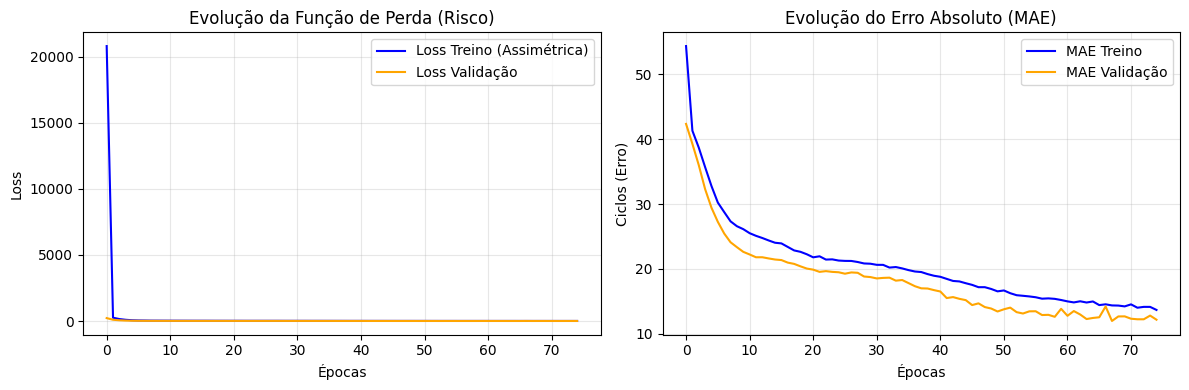

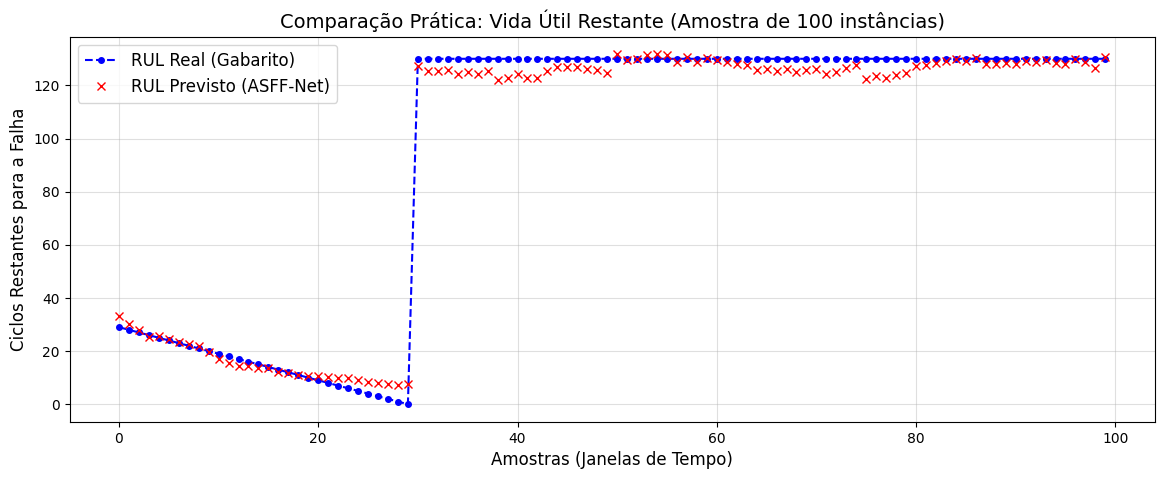

In [15]:
# 1. O comando mágico para forçar o Jupyter/Kaggle a mostrar os gráficos na tela
%matplotlib inline
import matplotlib.pyplot as plt

# 2. Gerar as predições novamente apenas para o gráfico (super rápido)
y_pred = model.predict(X_val)

print("A desenhar os gráficos...")

# ==========================================
# GRÁFICO 1: Curvas de Aprendizagem (Loss e MAE)
# ==========================================
plt.figure(figsize=(12, 4))

# Subgráfico da Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss Treino (Assimétrica)', color='blue')
plt.plot(history.history['val_loss'], label='Loss Validação', color='orange')
plt.title('Evolução da Função de Perda (Risco)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfico do Erro MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE Treino', color='blue')
plt.plot(history.history['val_mae'], label='MAE Validação', color='orange')
plt.title('Evolução do Erro Absoluto (MAE)')
plt.xlabel('Épocas')
plt.ylabel('Ciclos (Erro)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 2: RUL Real vs. RUL Previsto
# ==========================================
plt.figure(figsize=(14, 5))

# Plotamos apenas as primeiras 100 amostras para o gráfico não ficar uma mancha ilegível
plt.plot(y_val[:100], label='RUL Real (Gabarito)', color='blue', marker='o', linestyle='dashed', markersize=4)
plt.plot(y_pred[:100], label='RUL Previsto (ASFF-Net)', color='red', marker='x', linestyle='None', markersize=6)

plt.title('Comparação Prática: Vida Útil Restante (Amostra de 100 instâncias)', fontsize=14)
plt.xlabel('Amostras (Janelas de Tempo)', fontsize=12)
plt.ylabel('Ciclos Restantes para a Falha', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.show()

### SALVAR MODELO E AVALIAÇÃO COM OS DADOS DE TESTE OFICIAIS (NASA)

In [16]:
# 1. Salvar os pesos do modelo na memória do Kaggle (Segurança em primeiro lugar!)
model.save('modelo_asff_net_treinado.keras')
print("✅ Seu modelo treinado foi salvo com sucesso como 'modelo_asff_net_treinado.keras'!")

# 2. Definir os caminhos dos arquivos de teste (Ajustados para o seu caminho do Kaggle)
caminho_teste = '/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/test_FD001.txt'
caminho_gabarito = '/kaggle/input/datasets/ryangabrielelesbo/nasa-cmaps-turbofan/RUL_FD001.txt'

# Reconstruir a estrutura de colunas original
colunas_originais = ['motor_id', 'ciclo', 'config_op_1', 'config_op_2', 'config_op_3'] + \
                    [f'sensor_{i}' for i in range(1, 22)]

print("\nCarregando dados de teste e gabarito oficial...")
df_teste = pd.read_csv(caminho_teste, sep=r'\s+', header=None, names=colunas_originais)
y_gabarito = pd.read_csv(caminho_gabarito, sep=r'\s+', header=None, names=['RUL_final'])

# 3. Pré-processamento dos Dados de Teste
# Mapear o ciclo máximo registrado para cada motor no teste
ciclo_max_teste = df_teste.groupby('motor_id')['ciclo'].max()
df_teste = df_teste.merge(ciclo_max_teste.to_frame(name='ciclo_maximo'), left_on='motor_id', right_index=True)

# Vincular o RUL real final do gabarito para cada motor correspondente
y_gabarito['motor_id'] = y_gabarito.index + 1
df_teste = df_teste.merge(y_gabarito, on='motor_id')

# Reconstruir a linha do tempo do RUL para o teste: (Ciclo Máximo - Ciclo Atual) + RUL restante do Gabarito
df_teste['RUL'] = (df_teste['ciclo_maximo'] - df_teste['ciclo']) + df_teste['RUL_final']

# Remover as colunas de ruído/fixas idênticas ao treino e colunas auxiliares
colunas_para_remover = [
    'config_op_1', 'config_op_2', 'config_op_3', 
    'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19',
    'ciclo_maximo', 'RUL_final'
]
df_teste.drop(colunas_para_remover, axis=1, inplace=True)

# Normalizar usando APENAS o transform do scaler original (para não vazar dados)
df_teste[sensores_restantes] = scaler.transform(df_teste[sensores_restantes])
print("✅ Dados de teste carregados e normalizados!")

# 4. Transformar em sequências temporais 3D
X_test_real, y_test_real = processar_dados_temporais(df_teste, SEQUENCE_LENGTH, sensores_restantes)

# 5. O Veredito: Chamar a função de avaliação nos dados oficiais da NASA
print("\n==================================================================")
print("📊 RESULTADOS FINAIS DA ASFF-NET NOS DADOS DE TESTE DA NASA 📊")
print("==================================================================")

avaliar_modelo(model, X_test_real, y_test_real, history=None, nome_conjunto="Teste Oficial NASA")

✅ Seu modelo treinado foi salvo com sucesso como 'modelo_asff_net_treinado.keras'!

Carregando dados de teste e gabarito oficial...
✅ Dados de teste carregados e normalizados!

📊 RESULTADOS FINAIS DA ASFF-NET NOS DADOS DE TESTE DA NASA 📊

--- Gerando Predições no Conjunto de Teste Oficial NASA ---
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ MAE (Erro Médio Absoluto): 13.24 ciclos
✅ RMSE (Raiz do Erro Quadrático Médio): 16.40 ciclos
🚀 SCORE OFICIAL NASA (CMAPSS): 45911.80
